In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


In [2]:
# Load face detection model (YOLOv8 - your friend's)
face_model_path = "../models/WIDER_FACE/runs/detect/face_detection/weights/best.pt"
face_detector = YOLO(face_model_path)
print(f"✅ Face detector loaded")

# Load expression model (Keras - yours or friend's)
expression_model_path = "../models/FER2013/best_fer2013_model.keras"  # or your trained model
expression_model = load_model(expression_model_path)
print(f"✅ Expression model loaded")

# Labels
EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

SENTIMENT_MAP = {
    'angry': 'Negative', 'disgust': 'Negative', 'fear': 'Negative',
    'happy': 'Positive', 'neutral': 'Neutral', 'sad': 'Negative',
    'surprise': 'Positive'
}

✅ Face detector loaded
✅ Expression model loaded


In [11]:
def analyze_image(image_path, conf_threshold=0.3):
    """
    Full pipeline: Detect faces -> Recognize expression -> Sentiment analysis
    """
    # Read image
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"❌ Cannot read image: {image_path}")
        return None
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Step 1: Detect faces
    results = face_detector(image_path, conf=conf_threshold, verbose=False)
    detections = results[0].boxes
    
    print(f"Detected {len(detections)} face(s)")
    
    # Step 2: Process each face
    face_results = []
    
    for i, box in enumerate(detections):
        # Get bounding box
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        conf = float(box.conf[0])
        
        # Crop face
        face_crop = image[y1:y2, x1:x2]
        if face_crop.size == 0:
            continue
        
        # Step 3: Expression recognition
        # Convert to grayscale and resize to 48x48
        face_gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)
        face_resized = cv2.resize(face_gray, (48, 48))
        face_input = face_resized.reshape(1, 48, 48, 1) / 255.0
        
        # Predict
        pred = expression_model.predict(face_input, verbose=0)
        pred_idx = np.argmax(pred)
        confidence = np.max(pred) * 100
        
        emotion = EMOTIONS[pred_idx]
        sentiment = SENTIMENT_MAP[emotion]
        
        face_results.append({
            'face_id': i + 1,
            'bbox': [x1, y1, x2, y2],
            'detection_conf': conf,
            'emotion': emotion,
            'emotion_conf': confidence,
            'sentiment': sentiment,
            'all_probs': {EMOTIONS[j]: pred[0][j] * 100 for j in range(7)}
        })
        
        print(f"  Face {i+1}: {emotion} ({confidence:.1f}%) -> {sentiment}")
    
    # Step 4: Visualize
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(image_rgb)
    
    for r in face_results:
        x1, y1, x2, y2 = r['bbox']
        
        # Draw box
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                            fill=False, edgecolor='lime', linewidth=2)
        ax.add_patch(rect)
        
        # Label
        label = f"{r['emotion']}\n{r['sentiment']}\n{r['emotion_conf']:.1f}%"
        ax.text(x1, y1-5, label, color='white', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='blue', alpha=0.7))
    
    ax.set_title(f"Face Detection + Expression + Sentiment Analysis\n{len(face_results)} face(s)")
    ax.axis('off')
    plt.tight_layout()
    plt.savefig("../results/integrated_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Step 5: Results table
    if face_results:
        df = pd.DataFrame([{
            'Face #': r['face_id'],
            'Emotion': r['emotion'],
            'Confidence': f"{r['emotion_conf']:.2f}%",
            'Sentiment': r['sentiment'],
            'Detection Conf': f"{r['detection_conf']:.3f}",
            'BBox': f"[{r['bbox'][0]}, {r['bbox'][1]}, {r['bbox'][2]}, {r['bbox'][3]}]"
        } for r in face_results])
        
        print("\nResults Table:")
        display(df)
        df.to_csv("../results/integrated_results.csv", index=False)
    
    return face_results

In [12]:
import random

# Find a test image
val_images = list(Path("data/wider_face/WIDER_val/images").rglob("*.jpg"))
if val_images:
    test_img = random.choice(val_images)
    print(f"Testing on: {test_img.name}")
    results = analyze_image(test_img)


ANALYZING: face.jpg
Detected 70 face(s)
  Face 1: happy (98.3%) -> Positive
  Face 2: happy (98.8%) -> Positive
  Face 3: happy (99.7%) -> Positive
  Face 4: happy (98.0%) -> Positive
  Face 5: happy (99.6%) -> Positive
  Face 6: happy (99.6%) -> Positive
  Face 7: happy (90.4%) -> Positive
  Face 8: happy (99.9%) -> Positive
  Face 9: happy (99.7%) -> Positive
  Face 10: happy (56.2%) -> Positive
  Face 11: happy (99.9%) -> Positive
  Face 12: happy (99.7%) -> Positive
  Face 13: happy (99.9%) -> Positive
  Face 14: happy (87.9%) -> Positive
  Face 15: happy (94.8%) -> Positive
  Face 16: happy (99.8%) -> Positive
  Face 17: happy (97.1%) -> Positive
  Face 18: happy (91.3%) -> Positive
  Face 19: happy (99.6%) -> Positive
  Face 20: happy (99.7%) -> Positive
  Face 21: happy (99.9%) -> Positive
  Face 22: happy (99.7%) -> Positive
  Face 23: happy (49.1%) -> Positive
  Face 24: happy (91.8%) -> Positive
  Face 25: happy (100.0%) -> Positive
  Face 26: happy (99.7%) -> Positive
  Fac

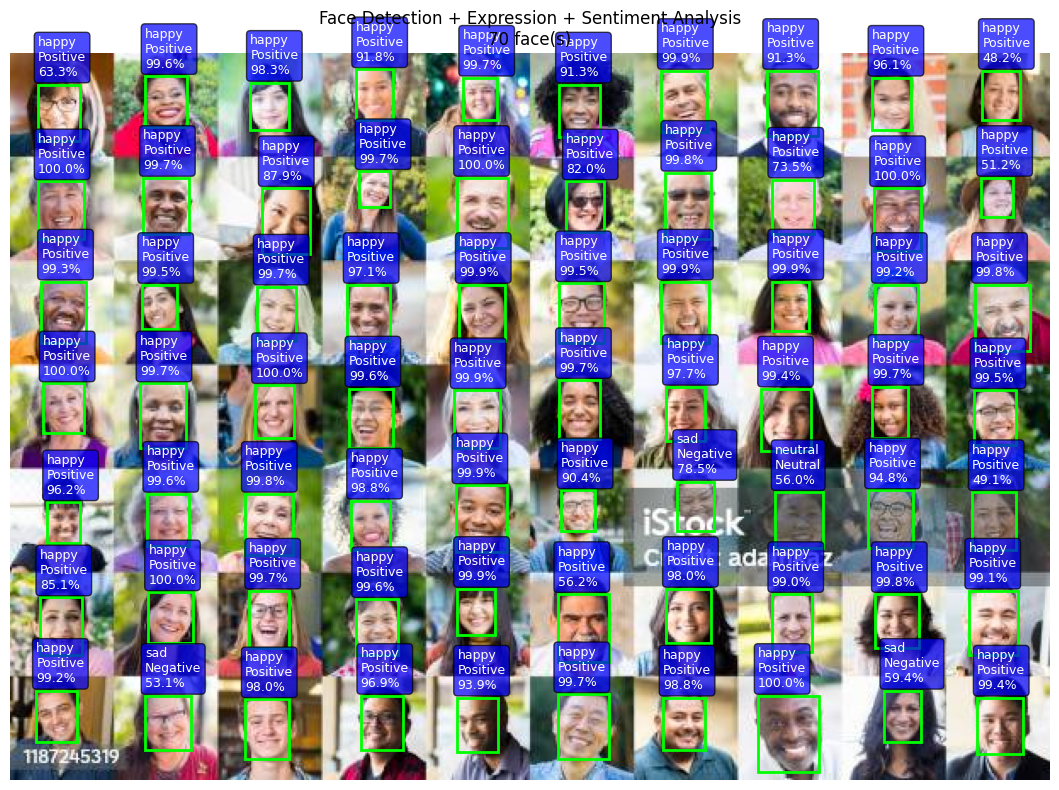


Results Table:


,Face #,Emotion,Confidence,Sentiment,Detection Conf,BBox
0,1,happy,98.31%,Positive,0.858,"[141, 17, 164, 45]"
1,2,happy,98.82%,Positive,0.855,"[384, 379, 409, 410]"
2,3,happy,99.73%,Positive,0.851,"[145, 137, 168, 169]"
3,4,happy,97.95%,Positive,0.851,"[138, 380, 164, 415]"
4,5,happy,99.60%,Positive,0.843,"[79, 13, 104, 43]"
...,...,...,...,...,...,...
65,66,happy,85.14%,Positive,0.791,"[17, 320, 42, 354]"
66,67,happy,99.73%,Positive,0.788,"[266, 14, 286, 39]"
67,68,happy,93.94%,Positive,0.770,"[263, 379, 287, 411]"
68,69,neutral,56.03%,Neutral,0.765,"[450, 258, 478, 291]"



SENTIMENT SUMMARY
  Positive: 66 face(s)
  Negative: 3 face(s)
  Neutral: 1 face(s)

  Overall: Negative emotions detected


[{'face_id': 1,
  'bbox': [141, 17, 164, 45],
  'detection_conf': 0.8575112223625183,
  'emotion': 'happy',
  'emotion_conf': np.float32(98.31484),
  'sentiment': 'Positive',
  'all_probs': {'angry': np.float32(0.028317815),
   'disgust': np.float32(0.008549793),
   'fear': np.float32(0.27890444),
   'happy': np.float32(98.31484),
   'neutral': np.float32(0.7380543),
   'sad': np.float32(0.6144745),
   'surprise': np.float32(0.016849138)}},
 {'face_id': 2,
  'bbox': [384, 379, 409, 410],
  'detection_conf': 0.8545573353767395,
  'emotion': 'happy',
  'emotion_conf': np.float32(98.82235),
  'sentiment': 'Positive',
  'all_probs': {'angry': np.float32(0.05444078),
   'disgust': np.float32(0.024772767),
   'fear': np.float32(0.03931044),
   'happy': np.float32(98.82235),
   'neutral': np.float32(0.27874947),
   'sad': np.float32(0.7733587),
   'surprise': np.float32(0.0070269736)}},
 {'face_id': 3,
  'bbox': [145, 137, 168, 169],
  'detection_conf': 0.8512325882911682,
  'emotion': 'happy

In [15]:
def test_custom_image(image_path):
    path = Path(image_path)
    if not path.exists():
        print(f"❌ Image not found: {path}")
        return None
    
    print(f"\n{'='*60}")
    print(f"ANALYZING: {path.name}")
    print(f"{'='*60}")
    
    results = analyze_image(path)
    
    print(f"\n{'='*60}")
    print("SENTIMENT SUMMARY")
    print(f"{'='*60}")
    
    if results:
        sentiments = [r['sentiment'] for r in results]
        from collections import Counter
        counts = Counter(sentiments)
        
        for sent, count in counts.items():
            print(f"  {sent}: {count} face(s)")
        
        # Overall sentiment
        if 'Negative' in counts:
            overall = "Negative emotions detected"
        elif 'Positive' in counts:
            overall = "Positive emotions detected"
        else:
            overall = "Neutral emotions detected"
        
        print(f"\n  Overall: {overall}")
    
    return results

# Example usage:
test_custom_image("../img/face.jpg")